In [1]:
!file /content/archive.zip

/content/archive.zip: cannot open `/content/archive.zip' (No such file or directory)


In [2]:
!mkdir -p /content/helmet_dataset
!unzip -q /content/archive.zip -d /content/helmet_dataset

print("Dataset extracted ✅")

unzip:  cannot find or open /content/archive.zip, /content/archive.zip.zip or /content/archive.zip.ZIP.
Dataset extracted ✅


In [3]:
!file /content/archive.zip

/content/archive.zip: cannot open `/content/archive.zip' (No such file or directory)


In [4]:
!ls -lh /content/archive.zip

ls: cannot access '/content/archive.zip': No such file or directory


In [5]:
!unzip -t /content/archive.zip | tail -5

unzip:  cannot find or open /content/archive.zip, /content/archive.zip.zip or /content/archive.zip.ZIP.
unzip:  cannot find or open /content/archive.zip, /content/archive.zip.zip or /content/archive.zip.ZIP.


In [6]:
!rm -rf /content/helmet_dataset
!mkdir -p /content/helmet_dataset
!unzip -q /content/archive.zip -d /content/helmet_dataset

unzip:  cannot find or open /content/archive.zip, /content/archive.zip.zip or /content/archive.zip.ZIP.


In [7]:
!rm -f /content/archive.zip
!rm -rf /content/helmet_dataset

In [8]:
!pip install -q kagglehub

In [9]:
import kagglehub

path = kagglehub.dataset_download(
    "brendan45774/bike-helmets-detection"
)

print("Dataset downloaded ✅")
print("Location:", path)

100%|██████████| 391M/391M [00:03<00:00, 131MB/s]

Extracting files...


Dataset downloaded ✅
Location: /root/.cache/kagglehub/datasets/brendan45774/bike-helmets-detection/versions/2


In [10]:
import os

for root, dirs, files in os.walk(path):
    level = root.replace(path, "").count(os.sep)

    if level <= 2:
        print("  " * level + os.path.basename(root) + "/")

        for file in files[:5]:
            print("  " * (level + 1) + file)

2/
  annotations/
    BikesHelmets49.xml
    BikesHelmets684.xml
    BikesHelmets506.xml
    BikesHelmets244.xml
    BikesHelmets44.xml
  images/
    BikesHelmets670.png
    BikesHelmets562.png
    BikesHelmets53.png
    BikesHelmets575.png
    BikesHelmets358.png


In [11]:
import glob
import os

images = (
    glob.glob(path + "/**/*.jpg", recursive=True) +
    glob.glob(path + "/**/*.jpeg", recursive=True) +
    glob.glob(path + "/**/*.png", recursive=True)
)

xml_files = glob.glob(
    path + "/**/*.xml",
    recursive=True
)

print("Images:", len(images))
print("XML annotations:", len(xml_files))

print("\nExample image:")
print(images[:1])

print("\nExample annotation:")
print(xml_files[:1])

Images: 764
XML annotations: 764

Example image:
['/root/.cache/kagglehub/datasets/brendan45774/bike-helmets-detection/versions/2/images/BikesHelmets670.png']

Example annotation:
['/root/.cache/kagglehub/datasets/brendan45774/bike-helmets-detection/versions/2/annotations/BikesHelmets49.xml']


In [12]:
print("Images:", len(images))
print("XML annotations:", len(xml_files))

Images: 764
XML annotations: 764


In [13]:
import os
import random
import shutil
import xml.etree.ElementTree as ET

# Create YOLO dataset folders
base = "/content/yolo_helmet"

for folder in [
    "images/train",
    "images/val",
    "labels/train",
    "labels/val"
]:
    os.makedirs(os.path.join(base, folder), exist_ok=True)

# Map image filename -> full path
image_map = {}

for img in images:
    stem = os.path.splitext(os.path.basename(img))[0]
    image_map[stem] = img

# Shuffle XML files
random.seed(42)
random.shuffle(xml_files)

# 80% train, 20% validation
split_index = int(len(xml_files) * 0.8)

train_xml = xml_files[:split_index]
val_xml = xml_files[split_index:]

print("Train XML:", len(train_xml))
print("Validation XML:", len(val_xml))

Train XML: 611
Validation XML: 153


In [14]:
class_names = [
    "With helmet",
    "Without helmet"
]

def convert_xml(xml_path, split):

    tree = ET.parse(xml_path)
    root = tree.getroot()

    filename = root.find("filename").text
    stem = os.path.splitext(filename)[0]

    image_path = image_map.get(stem)

    if image_path is None:
        return False

    size = root.find("size")

    width = int(size.find("width").text)
    height = int(size.find("height").text)

    yolo_lines = []

    for obj in root.findall("object"):

        class_name = obj.find("name").text.strip()

        if class_name not in class_names:
            continue

        class_id = class_names.index(class_name)

        bbox = obj.find("bndbox")

        xmin = float(bbox.find("xmin").text)
        ymin = float(bbox.find("ymin").text)
        xmax = float(bbox.find("xmax").text)
        ymax = float(bbox.find("ymax").text)

        x_center = ((xmin + xmax) / 2) / width
        y_center = ((ymin + ymax) / 2) / height

        box_width = (xmax - xmin) / width
        box_height = (ymax - ymin) / height

        yolo_lines.append(
            f"{class_id} {x_center} {y_center} {box_width} {box_height}"
        )

    # Copy image
    output_image = os.path.join(
        base,
        "images",
        split,
        os.path.basename(image_path)
    )

    shutil.copy(image_path, output_image)

    # Save YOLO label
    label_path = os.path.join(
        base,
        "labels",
        split,
        stem + ".txt"
    )

    with open(label_path, "w") as f:
        f.write("\n".join(yolo_lines))

    return True


train_count = 0
val_count = 0

for xml in train_xml:
    if convert_xml(xml, "train"):
        train_count += 1

for xml in val_xml:
    if convert_xml(xml, "val"):
        val_count += 1

print("Train converted:", train_count)
print("Validation converted:", val_count)

Train converted: 611
Validation converted: 153


In [15]:
print(
    "Train images:",
    len(os.listdir("/content/yolo_helmet/images/train"))
)

print(
    "Train labels:",
    len(os.listdir("/content/yolo_helmet/labels/train"))
)

print(
    "Validation images:",
    len(os.listdir("/content/yolo_helmet/images/val"))
)

print(
    "Validation labels:",
    len(os.listdir("/content/yolo_helmet/labels/val"))
)

Train images: 611
Train labels: 611
Validation images: 153
Validation labels: 153


In [16]:
yaml_text = """
path: /content/yolo_helmet

train: images/train
val: images/val

names:
  0: with_helmet
  1: without_helmet
"""

with open("/content/yolo_helmet/data.yaml", "w") as f:
    f.write(yaml_text)

print("data.yaml created ✅")

data.yaml created ✅


In [17]:
!pip install -q ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.9/46.9 kB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 13.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.1/58.1 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 96.1/96.1 kB 10.7 MB/s eta 0:00:00


In [18]:
from ultralytics import YOLO

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.


In [19]:
model = YOLO("yolo11n.pt")

results = model.train(
    data="/content/yolo_helmet/data.yaml",
    epochs=10,
    imgsz=640,
    batch=16,
    project="/content/helmet_project",
    name="training"
)

Ultralytics 8.4.174 🚀 Python-3.13.16 torch-2.11.0+cpu CPU (AMD EPYC 7B12)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/yolo_helmet/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=training, nbs=64, nms=None, opset=None, optimize=False, optimizer=aut

/usr/local/lib/python3.13/dist-packages/ultralytics/utils/metrics.py:892: RuntimeWarning: Mean of empty slice.
  i = smooth(f1_curve.mean(0), 0.1).argmax()  # max F1 index
/usr/local/lib/python3.13/dist-packages/numpy/_core/_methods.py:139: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(



      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
       2/10         0G          0      88.63          0          0        640: 100% ━━━━━━━━━━━━ 39/39 6.6s/it 4:17
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 5/5 4.4s/it 21.8s
                   all        153          0          0          0          0          0
WARNING ⚠️ no labels found in detect set, cannot compute metrics without labels


/usr/local/lib/python3.13/dist-packages/ultralytics/utils/metrics.py:892: RuntimeWarning: Mean of empty slice.
  i = smooth(f1_curve.mean(0), 0.1).argmax()  # max F1 index
/usr/local/lib/python3.13/dist-packages/numpy/_core/_methods.py:139: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(



      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
       3/10         0G          0      72.27          0          0        640: 100% ━━━━━━━━━━━━ 39/39 6.6s/it 4:19
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 5/5 4.2s/it 20.8s
                   all        153          0          0          0          0          0
WARNING ⚠️ no labels found in detect set, cannot compute metrics without labels

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


/usr/local/lib/python3.13/dist-packages/ultralytics/utils/metrics.py:892: RuntimeWarning: Mean of empty slice.
  i = smooth(f1_curve.mean(0), 0.1).argmax()  # max F1 index
/usr/local/lib/python3.13/dist-packages/numpy/_core/_methods.py:139: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


       4/10         0G          0      65.16          0          0        640: 23% ━━╸───────── 9/39 7.0s/it 1:08<3:30


KeyboardInterrupt: 

In [ ]:
!ls /content/helmet_project/training/weights

In [ ]:
from google.colab import files

uploaded = files.upload()

In [20]:
import xml.etree.ElementTree as ET

unique_classes = set()

for xml_path in xml_files:
    tree = ET.parse(xml_path)
    root = tree.getroot()

    for obj in root.findall("object"):
        name = obj.find("name").text.strip()
        unique_classes.add(name)

print("Classes found in XML:")
print(unique_classes)

Classes found in XML:
{'With Helmet', 'Without Helmet'}


In [21]:
import shutil
import os

shutil.rmtree("/content/yolo_helmet", ignore_errors=True)

base = "/content/yolo_helmet"

for folder in [
    "images/train",
    "images/val",
    "labels/train",
    "labels/val"
]:
    os.makedirs(os.path.join(base, folder), exist_ok=True)

print("Old incorrect dataset removed ✅")

Old incorrect dataset removed ✅


In [22]:
import os
import shutil
import random
import xml.etree.ElementTree as ET

class_names = [
    "With helmet",
    "Without helmet"
]

# Match image filename to actual path
image_map = {}

for img in images:
    stem = os.path.splitext(os.path.basename(img))[0]
    image_map[stem] = img

# Split 80% train / 20% validation
random.seed(42)

xml_copy = xml_files.copy()
random.shuffle(xml_copy)

split_index = int(len(xml_copy) * 0.8)

train_xml = xml_copy[:split_index]
val_xml = xml_copy[split_index:]


def convert_xml(xml_path, split):

    tree = ET.parse(xml_path)
    root = tree.getroot()

    filename = root.find("filename").text
    stem = os.path.splitext(filename)[0]

    image_path = image_map.get(stem)

    if image_path is None:
        return 0

    size = root.find("size")

    width = int(size.find("width").text)
    height = int(size.find("height").text)

    yolo_lines = []

    for obj in root.findall("object"):

        class_name = obj.find("name").text.strip()

        if class_name not in class_names:
            continue

        class_id = class_names.index(class_name)

        bbox = obj.find("bndbox")

        xmin = float(bbox.find("xmin").text)
        ymin = float(bbox.find("ymin").text)
        xmax = float(bbox.find("xmax").text)
        ymax = float(bbox.find("ymax").text)

        x_center = ((xmin + xmax) / 2) / width
        y_center = ((ymin + ymax) / 2) / height
        box_width = (xmax - xmin) / width
        box_height = (ymax - ymin) / height

        yolo_lines.append(
            f"{class_id} "
            f"{x_center:.6f} "
            f"{y_center:.6f} "
            f"{box_width:.6f} "
            f"{box_height:.6f}"
        )

    # Copy image
    shutil.copy(
        image_path,
        os.path.join(
            base,
            "images",
            split,
            os.path.basename(image_path)
        )
    )

    # Save YOLO label
    label_path = os.path.join(
        base,
        "labels",
        split,
        stem + ".txt"
    )

    with open(label_path, "w") as f:
        f.write("\n".join(yolo_lines))

    return len(yolo_lines)


train_boxes = 0
val_boxes = 0

for xml in train_xml:
    train_boxes += convert_xml(xml, "train")

for xml in val_xml:
    val_boxes += convert_xml(xml, "val")

print("Train images:", len(train_xml))
print("Validation images:", len(val_xml))

print("Training bounding boxes:", train_boxes)
print("Validation bounding boxes:", val_boxes)

Train images: 611
Validation images: 153
Training bounding boxes: 0
Validation bounding boxes: 0


In [23]:
from collections import Counter
import xml.etree.ElementTree as ET

class_counter = Counter()

for xml_path in xml_files:
    tree = ET.parse(xml_path)
    root = tree.getroot()

    for obj in root.findall("object"):
        name = obj.find("name").text
        class_counter[repr(name)] += 1

print(class_counter)

Counter({"'With Helmet'": 962, "'Without Helmet'": 489})


In [24]:
from collections import Counter
import xml.etree.ElementTree as ET

actual_classes = Counter()

for xml_path in xml_files:
    tree = ET.parse(xml_path)
    root = tree.getroot()

    for obj in root.findall("object"):
        name = obj.find("name").text.strip()
        actual_classes[name] += 1

print("Classes found:")
print(actual_classes)

class_names = list(actual_classes.keys())

print("Using classes:", class_names)

Classes found:
Counter({'With Helmet': 962, 'Without Helmet': 489})
Using classes: ['Without Helmet', 'With Helmet']


In [25]:
import os
import shutil
import random
import xml.etree.ElementTree as ET

shutil.rmtree("/content/yolo_helmet", ignore_errors=True)

base = "/content/yolo_helmet"

for folder in [
    "images/train",
    "images/val",
    "labels/train",
    "labels/val"
]:
    os.makedirs(os.path.join(base, folder), exist_ok=True)

# Image map
image_map = {}

for img in images:
    stem = os.path.splitext(os.path.basename(img))[0]
    image_map[stem] = img

# Split
xml_copy = xml_files.copy()
random.seed(42)
random.shuffle(xml_copy)

split_index = int(len(xml_copy) * 0.8)

train_xml = xml_copy[:split_index]
val_xml = xml_copy[split_index:]


def convert_xml(xml_path, split):
    tree = ET.parse(xml_path)
    root = tree.getroot()

    filename = root.find("filename").text
    stem = os.path.splitext(filename)[0]

    image_path = image_map.get(stem)

    if image_path is None:
        return 0

    size = root.find("size")

    width = int(size.find("width").text)
    height = int(size.find("height").text)

    yolo_lines = []

    for obj in root.findall("object"):

        class_name = obj.find("name").text.strip()

        if class_name not in class_names:
            continue

        class_id = class_names.index(class_name)

        bbox = obj.find("bndbox")

        xmin = float(bbox.find("xmin").text)
        ymin = float(bbox.find("ymin").text)
        xmax = float(bbox.find("xmax").text)
        ymax = float(bbox.find("ymax").text)

        x_center = ((xmin + xmax) / 2) / width
        y_center = ((ymin + ymax) / 2) / height
        box_width = (xmax - xmin) / width
        box_height = (ymax - ymin) / height

        yolo_lines.append(
            f"{class_id} "
            f"{x_center:.6f} "
            f"{y_center:.6f} "
            f"{box_width:.6f} "
            f"{box_height:.6f}"
        )

    shutil.copy(
        image_path,
        os.path.join(
            base,
            "images",
            split,
            os.path.basename(image_path)
        )
    )

    label_path = os.path.join(
        base,
        "labels",
        split,
        stem + ".txt"
    )

    with open(label_path, "w") as f:
        f.write("\n".join(yolo_lines))

    return len(yolo_lines)


train_boxes = sum(convert_xml(x, "train") for x in train_xml)
val_boxes = sum(convert_xml(x, "val") for x in val_xml)

print("Classes:", class_names)
print("Train images:", len(train_xml))
print("Validation images:", len(val_xml))
print("Training bounding boxes:", train_boxes)
print("Validation bounding boxes:", val_boxes)

Classes: ['Without Helmet', 'With Helmet']
Train images: 611
Validation images: 153
Training bounding boxes: 1144
Validation bounding boxes: 307


In [26]:
yaml_text = """
path: /content/yolo_helmet

train: images/train
val: images/val

names:
  0: without_helmet
  1: with_helmet
"""

with open("/content/yolo_helmet/data.yaml", "w") as f:
    f.write(yaml_text)

print(open("/content/yolo_helmet/data.yaml").read())


path: /content/yolo_helmet

train: images/train
val: images/val

names:
  0: without_helmet
  1: with_helmet



In [27]:
import glob
import os

labels = glob.glob("/content/yolo_helmet/labels/train/*.txt")

non_empty = [
    f for f in labels
    if os.path.getsize(f) > 0
]

print("Total label files:", len(labels))
print("Non-empty label files:", len(non_empty))

print("\nExample label:")
print(open(non_empty[0]).read())

Total label files: 611
Non-empty label files: 610

Example label:
1 0.776250 0.166667 0.082500 0.161049
1 0.607500 0.325843 0.125000 0.202247
1 0.477500 0.307116 0.090000 0.142322
1 0.333750 0.290262 0.087500 0.168539


In [28]:
!pip install -q ultralytics

In [29]:
from ultralytics import YOLO

model = YOLO("yolo11n.pt")

results = model.train(
    data="/content/yolo_helmet/data.yaml",
    epochs=10,
    imgsz=640,
    batch=16,
    project="/content/helmet_project",
    name="training_fixed"
)

Ultralytics 8.4.174 🚀 Python-3.13.16 torch-2.11.0+cpu CPU (AMD EPYC 7B12)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/yolo_helmet/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=training_fixed, nbs=64, nms=None, opset=None, optimize=False, optimiz

In [30]:
!ls /content/helmet_project/training_fixed/weights

best.pt  last.pt


In [31]:
from ultralytics import YOLO

model = YOLO(
    "/content/helmet_project/training_fixed/weights/best.pt"
)

print("Best model loaded ✅")

Best model loaded ✅


In [34]:
from google.colab import files

uploaded = files.upload()

Saving dc-Cover-mdmk6mpl3ea84k1cn6pln9rrv5-20160306024001.Medi.jpeg to dc-Cover-mdmk6mpl3ea84k1cn6pln9rrv5-20160306024001.Medi.jpeg


In [35]:
image_name = list(uploaded.keys())[0]
image_path = "/content/" + image_name

results = model.predict(
    source=image_path,
    conf=0.4,
    save=True
)

print("Detection complete ✅")


image 1/1 /content/dc-Cover-mdmk6mpl3ea84k1cn6pln9rrv5-20160306024001.Medi.jpeg: 384x640 3 without_helmets, 86.6ms
Speed: 2.8ms preprocess, 86.6ms inference, 1.2ms postprocess per image at shape (1, 3, 384, 640)
Results saved to /content/runs/detect/predict
Detection complete ✅


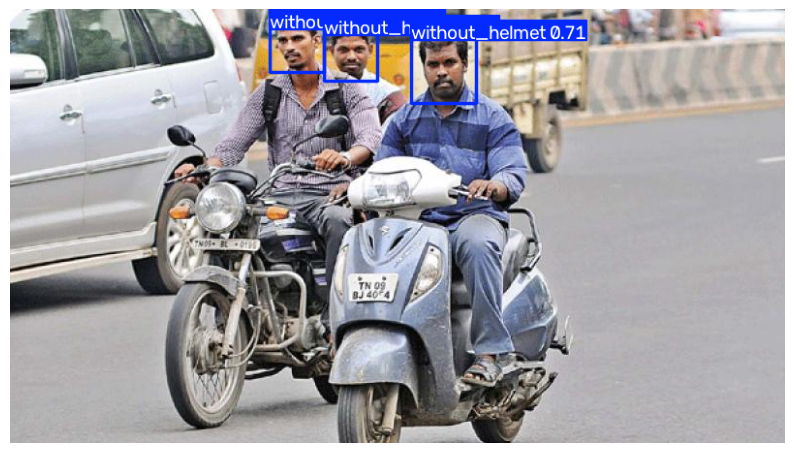

In [36]:
import matplotlib.pyplot as plt

result_image = results[0].plot()

plt.figure(figsize=(10, 8))
plt.imshow(result_image[:, :, ::-1])
plt.axis("off")
plt.show()

In [37]:
metrics = model.val(
    data="/content/yolo_helmet/data.yaml"
)

print("mAP50:", metrics.box.map50)
print("mAP50-95:", metrics.box.map)
print("Precision:", metrics.box.mp)
print("Recall:", metrics.box.mr)

Ultralytics 8.4.174 🚀 Python-3.13.16 torch-2.11.0+cpu CPU (AMD EPYC 7B12)
YOLO11n summary (fused): 100 layers, 2,582,542 parameters, 0 gradients, 6.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 3910.1±1371.8 MB/s, size: 487.1 KB)
val: Scanning /content/yolo_helmet/labels/val.cache... 153 images, 2 backgrounds, 1 corrupt: 100% ━━━━━━━━━━━━ 153/153 35.7Mit/s 0.0s
val: /content/yolo_helmet/images/val/BikesHelmets140.png: ignoring corrupt image/label: non-normalized or out of bounds coordinates [547.685  84.5   132.165 151.   ]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 10/10 1.6s/it 16.0s
                   all        152        305      0.768      0.807      0.813      0.497
        without_helmet         55        101      0.746      0.727      0.765      0.442
           with_helmet        112        204       0.79      0.887      0.861      0.551
Speed: 0.6ms preprocess, 86.1ms inference, 0.0ms loss, 1.7ms p

In [38]:
from ultralytics import YOLO

model = YOLO(
    "/content/helmet_project/training_fixed/weights/best.pt"
)

model.export(
    format="onnx",
    imgsz=640,
    simplify=True
)

print("ONNX model created ✅")

Ultralytics 8.4.174 🚀 Python-3.13.16 torch-2.11.0+cpu CPU (AMD EPYC 7B12)
YOLO11n summary (fused): 100 layers, 2,582,542 parameters, 0 gradients, 6.4 GFLOPs

PyTorch: starting from '/content/helmet_project/training_fixed/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 6, 8400) (5.2 MB)
requirements: Ultralytics requirements ['onnx>=1.12.0,<2.0.0', 'onnxruntime', 'onnxslim>=0.1.82'] not found, attempting AutoUpdate...
Using Python 3.13.16 environment at: /usr
Resolved 12 packages in 617ms
Prepared 4 packages in 609ms
Installed 4 packages in 29ms
 + colorama==0.4.6
 + onnx==1.23.2
 + onnxruntime==1.30.0
 + onnxslim==0.1.98

requirements: AutoUpdate success ✅ 1.7s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


ONNX: starting export with onnx 1.23.2 opset 18...
ONNX: slimming with onnxslim 0.1.98...
ONNX: export success ✅ 3.7s, saved as '/content/helmet_project/training_fixed/weights/best.onnx' (10.1 MB)

Export comple

In [39]:
!find /content -name "*.onnx"

/content/helmet_project/training_fixed/weights/best.onnx


In [40]:
from google.colab import files

files.download(
    "/content/helmet_project/training_fixed/weights/best.onnx"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [41]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [42]:
import os

drive_project = "/content/drive/MyDrive/SafeVision_AI"
os.makedirs(drive_project, exist_ok=True)

print("Drive folder created:", drive_project)

Drive folder created: /content/drive/MyDrive/SafeVision_AI


In [43]:
import shutil
import os

items_to_save = [
    "/content/yolo_helmet",
    "/content/helmet_project",
    "/content/runs",
    "/content/archive.zip",
]

for item in items_to_save:
    if os.path.exists(item):
        name = os.path.basename(item)
        destination = os.path.join(drive_project, name)

        if os.path.isdir(item):
            if os.path.exists(destination):
                shutil.rmtree(destination)
            shutil.copytree(item, destination)
        else:
            shutil.copy2(item, destination)

        print("Saved:", item)
    else:
        print("Not found:", item)

print("✅ Main project files saved to Google Drive")

Saved: /content/yolo_helmet
Saved: /content/helmet_project
Saved: /content/runs
Not found: /content/archive.zip
✅ Main project files saved to Google Drive


In [44]:
import glob
import shutil
import os

onnx_files = glob.glob("/content/**/*.onnx", recursive=True)

for file in onnx_files:
    destination = os.path.join(
        drive_project,
        os.path.basename(file)
    )
    shutil.copy2(file, destination)
    print("Saved ONNX:", destination)

Saved ONNX: /content/drive/MyDrive/SafeVision_AI/best.onnx
Saved ONNX: /content/drive/MyDrive/SafeVision_AI/best.onnx


In [45]:
final_model_dir = os.path.join(drive_project, "final_model")
os.makedirs(final_model_dir, exist_ok=True)

best_pt = "/content/helmet_project/training_fixed/weights/best.pt"

if os.path.exists(best_pt):
    shutil.copy2(
        best_pt,
        os.path.join(final_model_dir, "best.pt")
    )

for f in glob.glob("/content/**/*.onnx", recursive=True):
    shutil.copy2(
        f,
        os.path.join(final_model_dir, "best.onnx")
    )

print("✅ Final models backed up")

✅ Final models backed up
